# Import

In [6]:
from sqlalchemy import create_engine #Used to Connect to SQL DB
import urllib #Used to Connect to SQL DB
import urllib.parse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Connect To SQL DB

In [15]:
load_dotenv()
conn = (
"DRIVER={ODBC Driver 18 for SQL Server};"
f"SERVER={os.environ['SQL_HOST']};"
"DATABASE=AdventureWorksDW2025;"
f"UID={os.environ['SQL_USER']};"
f"PWD={os.environ['SQL_PASSWORD']};"
"TrustServerCertificate=yes;"
"Connection Timeout=5;"
)
params = urllib.parse.quote_plus(conn)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Exploratory Data Analysis

## List All Tables

In [16]:
sql_query = "SELECT name FROM AdventureWorksDW2025.sys.tables;"
df = pd.read_sql(sql_query, engine)
df.head(5)

,name
0,DatabaseLog
1,AdventureWorksDWBuildVersion
2,DimAccount
3,DimCurrency
4,DimCustomer


## List All Views

In [9]:
sql_query = "SELECT name FROM AdventureWorksDW2025.sys.views;"
df = pd.read_sql(sql_query, engine)
df.head(10)

,name
0,vDMPrep
1,vTimeSeries
2,vTargetMail
3,vAssocSeqOrders
4,vAssocSeqLineItems
5,vw_DimProduct
6,vw_FactInternetSales
7,vw_FactResellerSales
8,vw_DimGeography
9,vw_DimDate


## Examine FactInternetSales Table

In [41]:
df = pd.read_sql("SELECT * FROM vw_FactInternetSales", engine)

In [42]:
df.info() # Get table columns and properties

<class 'pandas.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SalesOrderNumber      60398 non-null  str    
 1   SalesOrderLineNumber  60398 non-null  int64  
 2   CustomerKey           60398 non-null  int64  
 3   ProductKey            60398 non-null  int64  
 4   OrderDateKey          60398 non-null  int64  
 5   OrderQuantity         60398 non-null  int64  
 6   UnitPrice             60398 non-null  float64
 7   SalesAmount           60398 non-null  float64
 8   TotalProductCost      60398 non-null  float64
 9   GrossProfit           60398 non-null  float64
dtypes: float64(4), int64(5), str(1)
memory usage: 5.0 MB


In [43]:
nulls = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100,
})
nulls.sort_values('percent', ascending=False)

,count,percent
SalesOrderNumber,0,0.0
SalesOrderLineNumber,0,0.0
CustomerKey,0,0.0
ProductKey,0,0.0
OrderDateKey,0,0.0
OrderQuantity,0,0.0
UnitPrice,0,0.0
SalesAmount,0,0.0
TotalProductCost,0,0.0
GrossProfit,0,0.0


In [44]:
df.duplicated().sum() # Check for Duplicates

np.int64(0)

## Examine FactResellerSales

In [48]:
df = pd.read_sql("SELECT * FROM vw_FactResellerSales;", engine)

In [49]:
df.info() # Get table columns and properties

<class 'pandas.DataFrame'>
RangeIndex: 60855 entries, 0 to 60854
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SalesOrderNumber      60855 non-null  str    
 1   SalesOrderLineNumber  60855 non-null  int64  
 2   ResellerKey           60855 non-null  int64  
 3   EmployeeKey           60855 non-null  int64  
 4   ProductKey            60855 non-null  int64  
 5   OrderDateKey          60855 non-null  int64  
 6   SalesTerritoryKey     60855 non-null  int64  
 7   OrderQuantity         60855 non-null  int64  
 8   UnitPrice             60855 non-null  float64
 9   ExtendedAmount        60855 non-null  float64
 10  TotalProductCost      60855 non-null  float64
 11  SalesAmount           60855 non-null  float64
 12  GrossProfit           60855 non-null  float64
 13  ChannelName           60855 non-null  str    
dtypes: float64(5), int64(7), str(2)
memory usage: 7.4 MB


In [50]:
nulls = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100,
})
nulls.sort_values('percent', ascending=False)

,count,percent
SalesOrderNumber,0,0.0
SalesOrderLineNumber,0,0.0
ResellerKey,0,0.0
EmployeeKey,0,0.0
ProductKey,0,0.0
OrderDateKey,0,0.0
SalesTerritoryKey,0,0.0
OrderQuantity,0,0.0
UnitPrice,0,0.0
ExtendedAmount,0,0.0


In [51]:
df.duplicated().sum() # Check for Duplicates

np.int64(0)

## Examine DimProduct Table

In [52]:
df = pd.read_sql("SELECT * FROM vw_DimProduct;", engine)

In [53]:
df.info() # Get table columns and properties

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductKey    397 non-null    int64  
 1   ProductSKU    397 non-null    str    
 2   ProductName   397 non-null    str    
 3   ModelName     397 non-null    str    
 4   Class         397 non-null    str    
 5   Style         397 non-null    str    
 6   StandardCost  395 non-null    float64
 7   ListPrice     395 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 44.2 KB


In [54]:
nulls = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100,
})
nulls.sort_values('percent', ascending=False)

,count,percent
StandardCost,2,0.503778
ListPrice,2,0.503778
ProductKey,0,0.000000
ProductSKU,0,0.000000
ModelName,0,0.000000
ProductName,0,0.000000
Style,0,0.000000
Class,0,0.000000


In [55]:
df.duplicated().sum() # Check for Duplicates

np.int64(0)

## Join Tables

In [18]:
sql_query = """
SELECT p.EnglishProductName AS ProductName,
'Internet' AS SalesChannel,
f.OrderDate, f.SalesAmount
FROM FactInternetSales f
JOIN DimProduct p ON f.ProductKey = p.ProductKey
UNION ALL
SELECT p.EnglishProductName AS ProductName,
'Reseller' AS SalesChannel,
f.OrderDate, f.SalesAmount
FROM FactResellerSales f
JOIN DimProduct p ON f.ProductKey = p.ProductKey
"""

In [19]:
df = pd.read_sql(sql_query, engine)

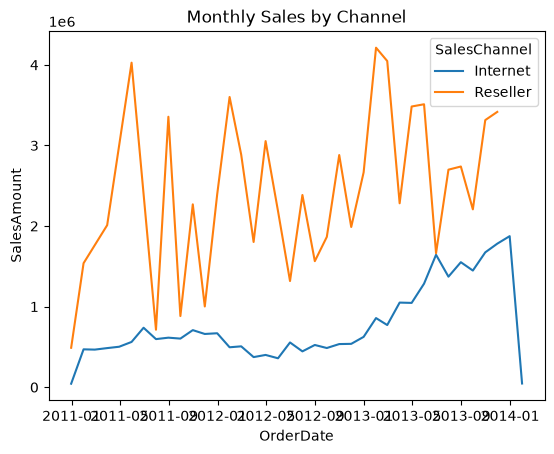

In [21]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
monthly = df.groupby([pd.Grouper(key='OrderDate', freq='ME'),
'SalesChannel'])['SalesAmount'].sum().reset_index()
sns.lineplot(data=monthly, x='OrderDate', y='SalesAmount', hue='SalesChannel')
plt.title('Monthly Sales by Channel')
plt.show()